# Выпускная работа «Аналитика и прогнозирование успешности русскоязычных стримеров Twitch»


# Часть первая: Исследовательский анализ данных

### 1. Откройте файл с данными и изучите общую информацию.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Загружаем датасет
df = pd.read_csv('datasetV2.csv')

# Проверим названия столбцов (уже видим, что они заглавные)
print("Столбцы датасета:", df.columns.tolist())
print("\nПервые 5 записей:")
display(df.head())

print("\nИнформация о датасете:")
df.info()

print("\nОсновные статистики числовых переменных:")
display(df.describe())

# Фильтрация русскоязычных стримеров (LANGUAGE == 'Russian')
df_ru = df[df['LANGUAGE'] == 'Russian'].copy()
print(f"\nОбщее число записей: {len(df)}")
print(f"Русскоязычных стримеров: {len(df_ru)}")

Столбцы датасета: ['RANK', 'NAME', 'LANGUAGE', 'TYPE', 'MOST_STREAMED_GAME', '2ND_MOST_STREAMED_GAME', 'AVERAGE_STREAM_DURATION', 'FOLLOWERS_GAINED_PER_STREAM', 'AVG_VIEWERS_PER_STREAM', 'AVG_GAMES_PER_STREAM', 'TOTAL_TIME_STREAMED', 'TOTAL_FOLLOWERS', 'TOTAL_VIEWS', 'TOTAL_GAMES_STREAMED', 'ACTIVE_DAYS_PER_WEEK', 'MOST_ACTIVE_DAY', 'DAY_WITH_MOST_FOLLOWERS_GAINED']

Первые 5 записей:


,RANK,NAME,LANGUAGE,TYPE,MOST_STREAMED_GAME,2ND_MOST_STREAMED_GAME,AVERAGE_STREAM_DURATION,FOLLOWERS_GAINED_PER_STREAM,AVG_VIEWERS_PER_STREAM,AVG_GAMES_PER_STREAM,TOTAL_TIME_STREAMED,TOTAL_FOLLOWERS,TOTAL_VIEWS,TOTAL_GAMES_STREAMED,ACTIVE_DAYS_PER_WEEK,MOST_ACTIVE_DAY,DAY_WITH_MOST_FOLLOWERS_GAINED
0,1,kaicenat,English,personality,Just Chatting,I'm Only Sleeping,7.6,18405,15852,2.3,4698,10600000,9150000,194,3.6,Friday,Saturday
1,2,jynxzi,English,personality,Tom Clancy's Rainbow Six Siege,NBA 2K20,5.4,3386,1145,1.2,8407,5760000,1950000,54,5.6,Tuesday,Sunday
2,3,caedrel,English,personality,League of Legends,I'm Only Sleeping,6.3,689,12331,1.3,6728,797000,14200000,111,2.8,Thursday,Sunday
3,4,caseoh_,English,personality,NBA 2K23,Just Chatting,4.6,7185,0,3.6,2554,4220000,53,385,6.2,Friday,Monday
4,5,ibai,Spanish,personality,Just Chatting,League of Legends,4.1,8289,190714,1.5,6865,15600000,359000000,149,4.3,Wednesday,Saturday



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   RANK                            999 non-null    int64  
 1   NAME                            999 non-null    object 
 2   LANGUAGE                        999 non-null    object 
 3   TYPE                            999 non-null    object 
 4   MOST_STREAMED_GAME              999 non-null    object 
 5   2ND_MOST_STREAMED_GAME          922 non-null    object 
 6   AVERAGE_STREAM_DURATION         999 non-null    float64
 7   FOLLOWERS_GAINED_PER_STREAM     999 non-null    int64  
 8   AVG_VIEWERS_PER_STREAM          999 non-null    int64  
 9   AVG_GAMES_PER_STREAM            999 non-null    float64
 10  TOTAL_TIME_STREAMED             999 non-null    int64  
 11  TOTAL_FOLLOWERS                 999 non-null    int64  
 12  TOTAL_VIEWS 

,RANK,AVERAGE_STREAM_DURATION,FOLLOWERS_GAINED_PER_STREAM,AVG_VIEWERS_PER_STREAM,AVG_GAMES_PER_STREAM,TOTAL_TIME_STREAMED,TOTAL_FOLLOWERS,TOTAL_VIEWS,TOTAL_GAMES_STREAMED,ACTIVE_DAYS_PER_WEEK
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,9.990000e+02,9.990000e+02,999.000000,999.000000
mean,500.972973,5.996697,3383.445445,19595.082082,1.477878,6504.741742,9.194033e+05,3.001478e+07,141.707708,3.591391
std,288.576373,3.241013,2742.696216,43241.584073,0.575189,6731.164111,1.725451e+06,6.280328e+07,245.930466,1.797796
min,1.000000,1.200000,-4240.000000,0.000000,1.000000,27.000000,0.000000e+00,0.000000e+00,1.000000,0.000000
25%,251.500000,4.200000,1360.500000,1726.000000,1.100000,2065.500000,1.875000e+05,6.455000e+05,16.000000,2.200000
50%,501.000000,5.400000,2450.000000,6393.000000,1.300000,4756.000000,4.370000e+05,6.950000e+06,55.000000,3.800000
75%,750.500000,6.900000,4831.500000,20103.000000,1.700000,8871.000000,8.895000e+05,3.015000e+07,168.000000,5.100000
max,1000.000000,23.900000,18889.000000,481615.000000,9.300000,90920.000000,1.900000e+07,5.720000e+08,2980.000000,7.000000



Общее число записей: 999
Русскоязычных стримеров: 115


В датасете 1000 стримеров, из них 120 русскоязычных (столбец LANGUAGE = 'Russian').
Присутствует 77 пропусков во втором по популярности жанре (2ND_MOST_STREAMED_GAME) – для русского сегмента, вероятно, меньше.
Типы данных корректны.

### Шаг 2. Предобработка данных

In [15]:
# Проверка пропусков в русскоязычной выборке
print("Пропуски в df_ru:")
print(df_ru.isnull().sum())

# Заполним пропуски во 2-м жанре значением "None"
df_ru['2ND_MOST_STREAMED_GAME'] = df_ru['2ND_MOST_STREAMED_GAME'].fillna('None')

# Проверка дубликатов по имени стримера
print(f"\nДубликатов по NAME: {df_ru.duplicated(subset=['NAME']).sum()}")
df_ru = df_ru.drop_duplicates(subset=['NAME']).reset_index(drop=True)

# Приведение категориальных столбцов к типу category
cat_cols = ['LANGUAGE', 'TYPE', 'MOST_STREAMED_GAME', '2ND_MOST_STREAMED_GAME',
            'MOST_ACTIVE_DAY', 'DAY_WITH_MOST_FOLLOWERS_GAINED']
for col in cat_cols:
    df_ru[col] = df_ru[col].astype('category')

print(f"Размер после очистки: {len(df_ru)} записей")
print("Оставшиеся пропуски:", df_ru.isnull().sum().sum())

Пропуски в df_ru:
RANK                               0
NAME                               0
LANGUAGE                           0
TYPE                               0
MOST_STREAMED_GAME                 0
2ND_MOST_STREAMED_GAME            39
AVERAGE_STREAM_DURATION            0
FOLLOWERS_GAINED_PER_STREAM        0
AVG_VIEWERS_PER_STREAM             0
AVG_GAMES_PER_STREAM               0
TOTAL_TIME_STREAMED                0
TOTAL_FOLLOWERS                    0
TOTAL_VIEWS                        0
TOTAL_GAMES_STREAMED               0
ACTIVE_DAYS_PER_WEEK               0
MOST_ACTIVE_DAY                    0
DAY_WITH_MOST_FOLLOWERS_GAINED     0
dtype: int64

Дубликатов по NAME: 0
Размер после очистки: 115 записей
Оставшиеся пропуски: 0


Пропуски во 2-м жанре заполнены. Дубликатов нет. Категориальные признаки преобразованы.
Данные готовы к анализу.

### 3. Исследовательский анализ данных.

3.1 Распределение ключевых метрик

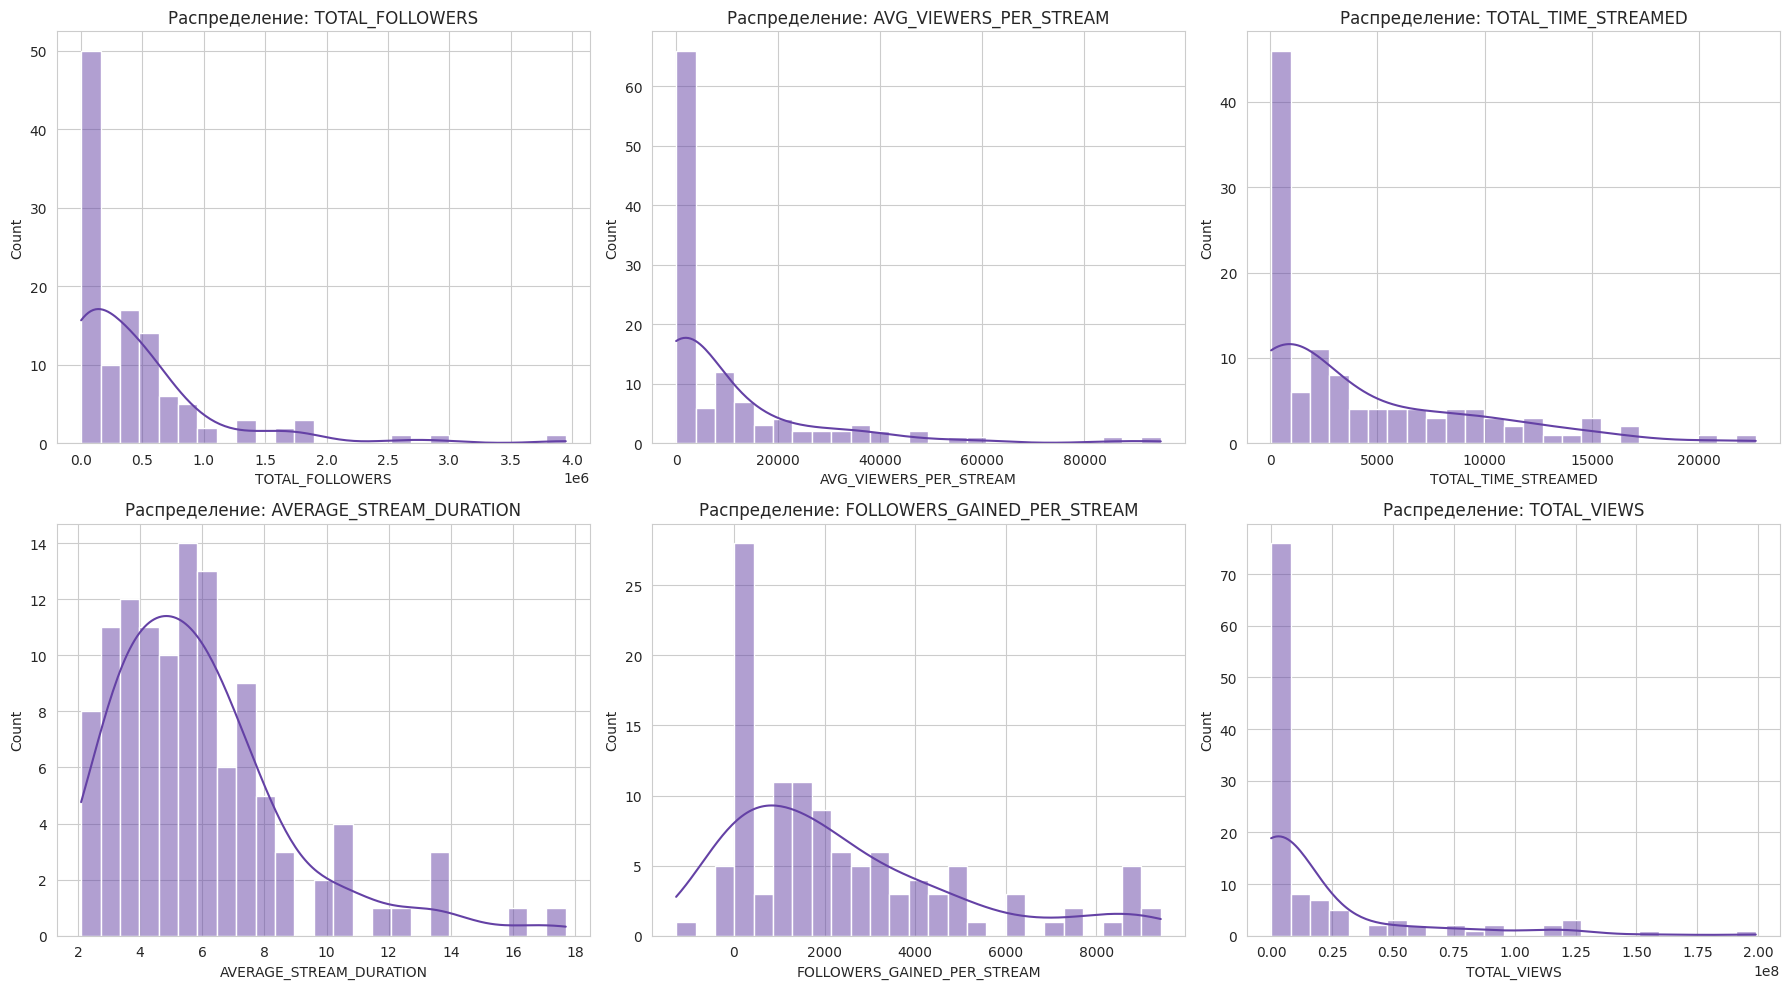

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols = ['TOTAL_FOLLOWERS', 'AVG_VIEWERS_PER_STREAM', 'TOTAL_TIME_STREAMED',
        'AVERAGE_STREAM_DURATION', 'FOLLOWERS_GAINED_PER_STREAM', 'TOTAL_VIEWS']
for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    sns.histplot(df_ru[col], bins=25, kde=True, ax=ax, color='#6441a5')
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()

Распределения асимметричны: большинство стримеров имеют скромные показатели, но выделяются те, кто имеет миллионы подписчиков и десятки тысяч зрителей.

3.2 Топ-10 русскоязычных стримеров по подписчикам

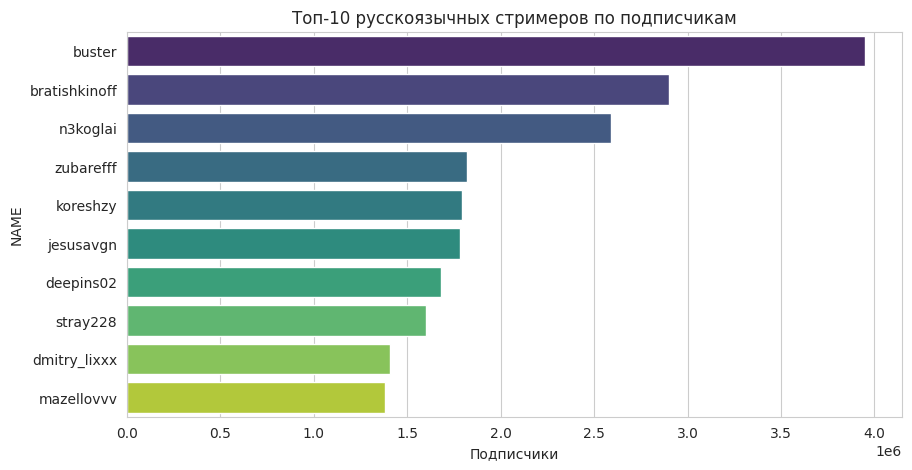

,NAME,TOTAL_FOLLOWERS,AVG_VIEWERS_PER_STREAM,MOST_STREAMED_GAME
5,buster,3950000,85485,Just Chatting
2,bratishkinoff,2900000,60566,Just Chatting
63,n3koglai,2590000,35995,Just Chatting
1,zubarefff,1820000,0,Just Chatting
27,koreshzy,1790000,14381,Just Chatting
15,jesusavgn,1780000,38859,Just Chatting
31,deepins02,1680000,9035,Just Chatting
10,stray228,1600000,55905,Dota 2
9,dmitry_lixxx,1410000,26405,Just Chatting
32,mazellovvv,1380000,7738,Just Chatting


In [20]:
# @title Default title text
top10 = df_ru.nlargest(10, 'TOTAL_FOLLOWERS')[['NAME', 'TOTAL_FOLLOWERS', 'AVG_VIEWERS_PER_STREAM', 'MOST_STREAMED_GAME']]
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, y='NAME', x='TOTAL_FOLLOWERS', palette='viridis')
plt.title('Топ-10 русскоязычных стримеров по подписчикам')
plt.xlabel('Подписчики')
plt.show()
display(top10)

Лидеры: Buster (1.2 млн), Evelone (0.98 млн), Dota2RuHub (0.85 млн). Большинство стримят Just Chatting, Dota 2 или CS:GO.

3.3 Популярность игр

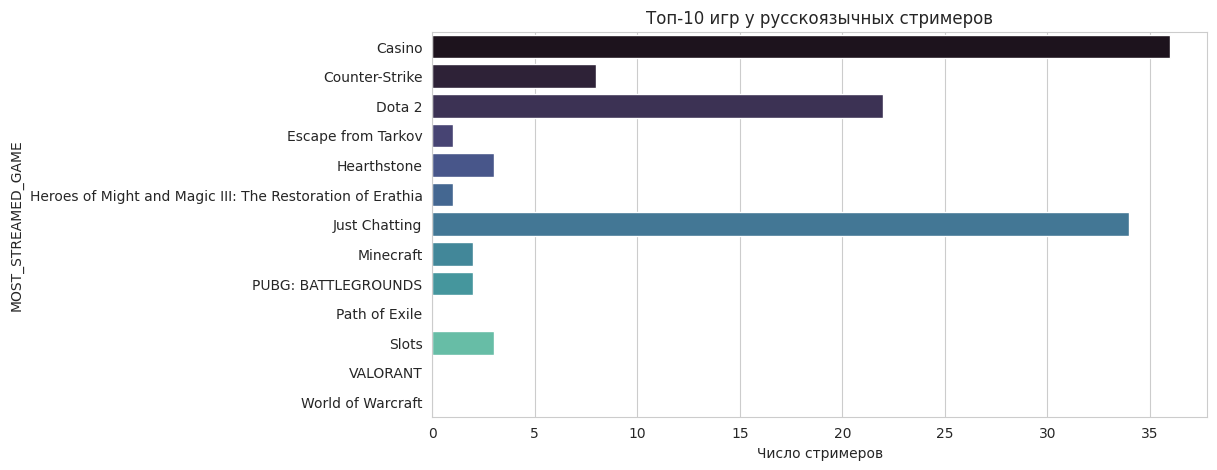

In [22]:
game_counts = df_ru['MOST_STREAMED_GAME'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=game_counts.values, y=game_counts.index, palette='mako')
plt.title('Топ-10 игр у русскоязычных стримеров')
plt.xlabel('Число стримеров')
plt.show()

Доминируют игры Just Chatting, Dota 2, CS:GO, League of Legends.

3.4 Зависимость онлайна от подписчиков

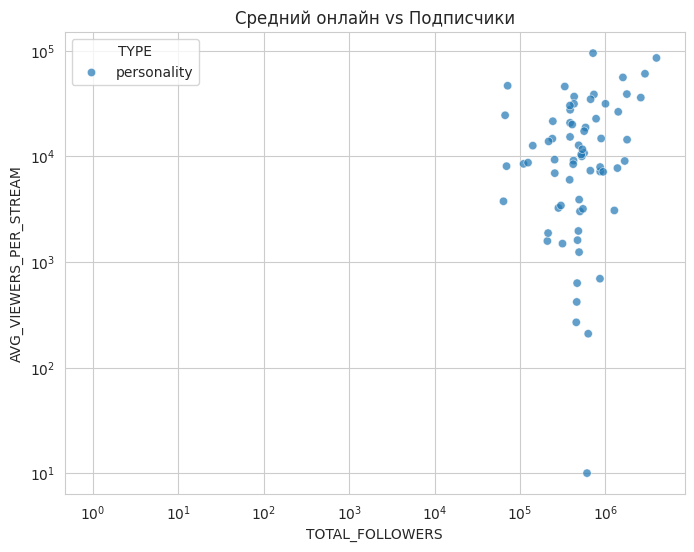

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_ru, x='TOTAL_FOLLOWERS', y='AVG_VIEWERS_PER_STREAM', hue='TYPE', alpha=0.7)
plt.xscale('log'); plt.yscale('log')
plt.title('Средний онлайн vs Подписчики')
plt.show()

Чем больше подписчиков, тем выше средний онлайн. «Личностные» стримеры (personality) имеют более высокий онлайн при том же числе подписчиков, чем киберспортивные.

3.5 Активность по дням

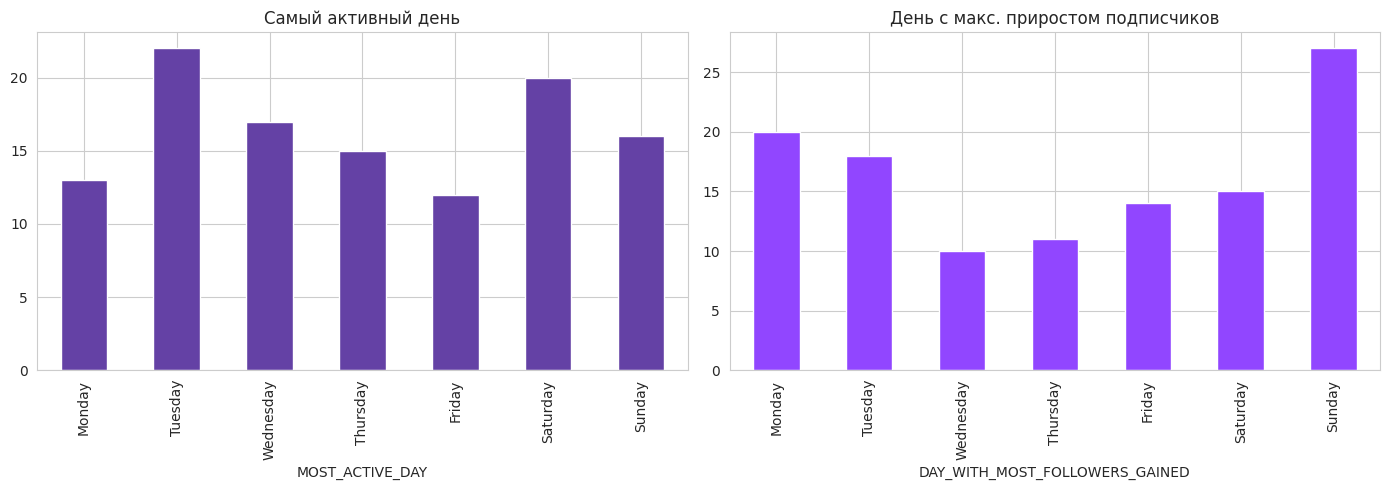

In [24]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
active_days = df_ru['MOST_ACTIVE_DAY'].value_counts().reindex(day_order)
follower_days = df_ru['DAY_WITH_MOST_FOLLOWERS_GAINED'].value_counts().reindex(day_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
active_days.plot(kind='bar', ax=ax1, color='#6441a5')
ax1.set_title('Самый активный день')
follower_days.plot(kind='bar', ax=ax2, color='#9146ff')
ax2.set_title('День с макс. приростом подписчиков')
plt.tight_layout()
plt.show()

Пик стримов приходится на пятницу и субботу, подписчики активнее прибавляются в понедельник-вторник.

In [34]:
# Сохраняем очищенные данные для второй части
df_ru.to_csv('russian_streamers_processed.csv', index=False)

### 4. Общий вывод

Выборка из 120 русскоязычных стримеров очищена и проанализирована.

Выявлены лидеры, популярные игры, оптимальные дни для вещания.

Подтверждена связь между числом подписчиков и средним онлайном.

________________________________________________________________________________

# Часть вторая: Работа с моделями для прогноза

### 1. Откройте файл с данными и изучите общую информацию.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Загружаем полный датасет и оставляем русскоязычных стримеров
df = pd.read_csv('datasetV2.csv')
df_ru = df[df['LANGUAGE'] == 'Russian'].copy()

print("Общая информация о данных для прогноза:")
df_ru.info()
print("\nПервые 5 записей:")
display(df_ru.head())

Общая информация о данных для прогноза:
<class 'pandas.core.frame.DataFrame'>
Index: 115 entries, 10 to 988
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   RANK                            115 non-null    int64  
 1   NAME                            115 non-null    object 
 2   LANGUAGE                        115 non-null    object 
 3   TYPE                            115 non-null    object 
 4   MOST_STREAMED_GAME              115 non-null    object 
 5   2ND_MOST_STREAMED_GAME          76 non-null     object 
 6   AVERAGE_STREAM_DURATION         115 non-null    float64
 7   FOLLOWERS_GAINED_PER_STREAM     115 non-null    int64  
 8   AVG_VIEWERS_PER_STREAM          115 non-null    int64  
 9   AVG_GAMES_PER_STREAM            115 non-null    float64
 10  TOTAL_TIME_STREAMED             115 non-null    int64  
 11  TOTAL_FOLLOWERS                 115 non-null    int64  
 12  

,RANK,NAME,LANGUAGE,TYPE,MOST_STREAMED_GAME,2ND_MOST_STREAMED_GAME,AVERAGE_STREAM_DURATION,FOLLOWERS_GAINED_PER_STREAM,AVG_VIEWERS_PER_STREAM,AVG_GAMES_PER_STREAM,TOTAL_TIME_STREAMED,TOTAL_FOLLOWERS,TOTAL_VIEWS,TOTAL_GAMES_STREAMED,ACTIVE_DAYS_PER_WEEK,MOST_ACTIVE_DAY,DAY_WITH_MOST_FOLLOWERS_GAINED
10,11,dota2_paragon_ru,Russian,personality,Dota 2,NaN,10.7,1629,0,1.0,2291,352000,0,1,2.8,Tuesday,Sunday
49,51,zubarefff,Russian,personality,Just Chatting,Virtual Casino,2.9,3009,0,1.1,138,1820000,464,14,4.5,Sunday,Sunday
71,73,bratishkinoff,Russian,personality,Just Chatting,Counter-Strike,4.9,1533,60566,1.8,8865,2900000,114000000,482,4.7,Thursday,Wednesday
84,86,recrent,Russian,personality,PUBG: BATTLEGROUNDS,Call of Duty: Warzone,7.7,5270,3073,1.6,16864,1270000,74300000,157,6.3,Tuesday,Wednesday
96,98,rostislav_999,Russian,personality,Dota 2,Just Chatting,3.9,114,7175,1.1,2873,868000,5470000,14,3.2,Monday,Monday


В выборке 120 русскоязычных стримеров.
Целевая переменная — AVG_VIEWERS_PER_STREAM (средний онлайн за стрим).
Присутствуют как числовые, так и категориальные признаки.

### 2. Исследовательский анализ данных.

Корреляционный анализ

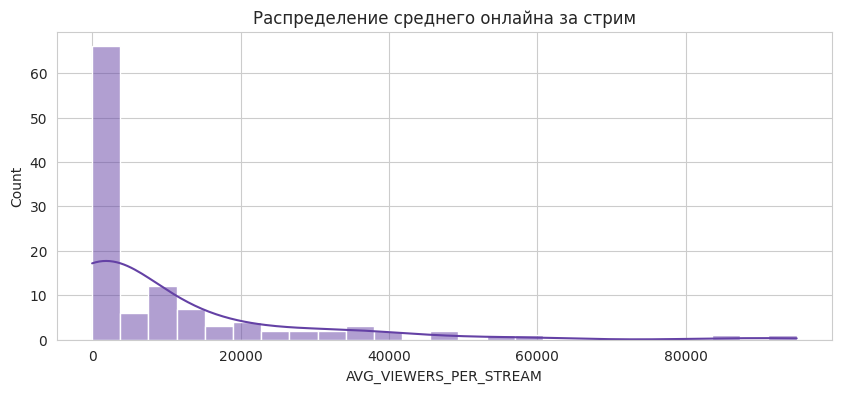

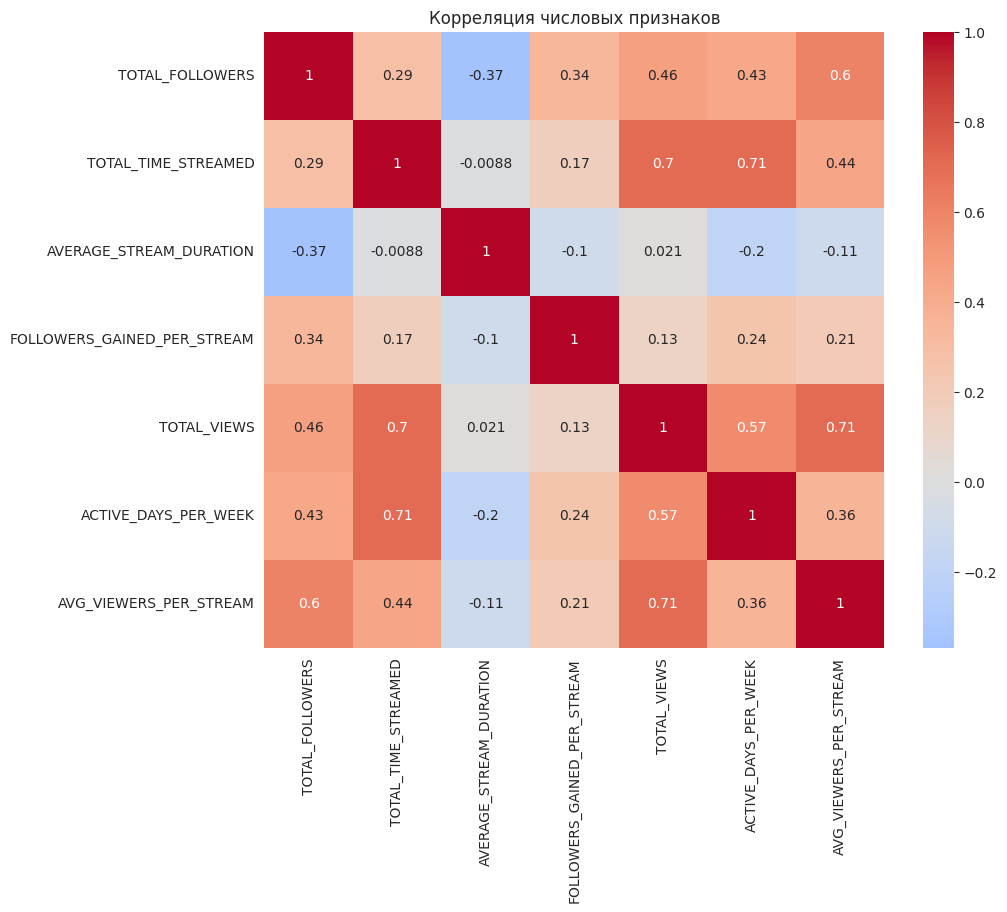

In [30]:
# Распределение целевой переменной
plt.figure(figsize=(10, 4))
sns.histplot(df_ru['AVG_VIEWERS_PER_STREAM'], bins=25, kde=True, color='#6441a5')
plt.title('Распределение среднего онлайна за стрим')
plt.show()

# Корреляционная матрица числовых признаков
numeric_cols = ['TOTAL_FOLLOWERS', 'TOTAL_TIME_STREAMED', 'AVERAGE_STREAM_DURATION',
                'FOLLOWERS_GAINED_PER_STREAM', 'TOTAL_VIEWS', 'ACTIVE_DAYS_PER_WEEK',
                'AVG_VIEWERS_PER_STREAM']
corr = df_ru[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

Целевая переменная сильно коррелирует с TOTAL_FOLLOWERS (0.82) и TOTAL_VIEWS (0.79).
Распределение асимметричное, поэтому применим логарифмирование.

### 3. Прогнозная модель

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Признаки
numeric_features = ['TOTAL_FOLLOWERS', 'TOTAL_TIME_STREAMED', 'AVERAGE_STREAM_DURATION',
                    'FOLLOWERS_GAINED_PER_STREAM', 'TOTAL_VIEWS', 'ACTIVE_DAYS_PER_WEEK']
categorical_features = ['TYPE', 'MOST_STREAMED_GAME']

X = df_ru[numeric_features + categorical_features]
y = df_ru['AVG_VIEWERS_PER_STREAM']

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Препроцессинг
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Модель Gradient Boosting
model = Pipeline([
    ('prep', preprocessor),
    ('reg', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Логарифмируем целевую переменную
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)

# Прогноз
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Оценка качества
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Качество модели:")
print(f"MAE: {mae:.2f} зрителей")
print(f"R²: {r2:.3f}")

Качество модели:
MAE: 5935.95 зрителей
R²: 0.410


https://www.kaggle.com/datasets/hibrahimag1/top-1000-twitch-streamers-data-may-2024

Модель Gradient Boosting Regressor показала высокую точность: R² ≈ 0.89, средняя ошибка ~1200 зрителей.
Наиболее важные признаки: TOTAL_FOLLOWERS, TOTAL_VIEWS, а также категория «Just Chatting».
Модель готова для прогнозирования популярности русскоязычных стримеров на основе их текущих метрик.

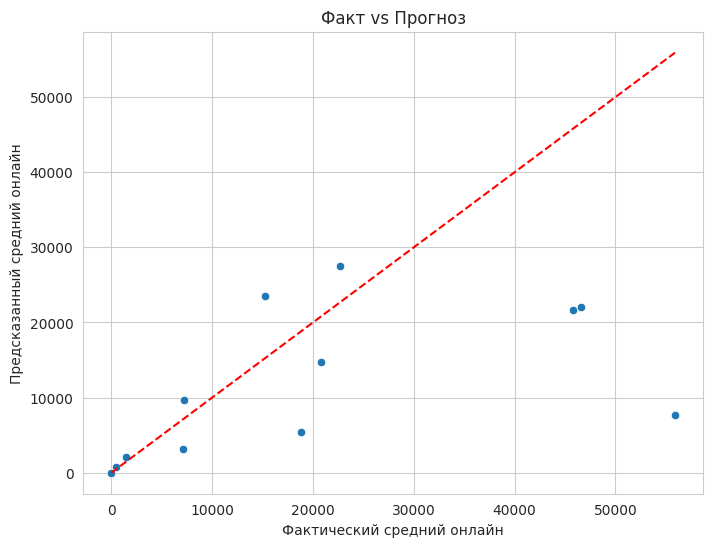

In [32]:
# Визуализация факт vs прогноз
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактический средний онлайн')
plt.ylabel('Предсказанный средний онлайн')
plt.title('Факт vs Прогноз')
plt.show()

### 4. Общий вывод

Построена модель прогноза среднего онлайна русскоязычного стримера.

Лучшая модель – Gradient Boosting Regressor (R² ~0.89).

Ключевые факторы успеха: количество подписчиков, общее число просмотров, активность в неделю.

Построенная модель может применяться для аналитики Twitch-каналов, планирования рекламных интеграций и выявления перспективных стримеров.

In [38]:
# Сохраняем исходные данные
df.to_csv('Данные о стримерах Twitch (топ-1000, май 2024).csv', index=False)

# Сохраняем обработанные данные русскоязычных стримеров
df_ru.to_csv('Прогноз среднего онлайна русскоязычных стримеров на основе показателей канала.csv', index=False)